# Two-Stage XGBoost v2 — Fixed Threshold Calibration

**What was wrong in v1:**  
The threshold sweep ran from 0.01 → 0.80 and selected `best_thresh = 0.80` (the boundary of the range) because Fatality F1 kept monotonically increasing. This is a trap: with extreme imbalance (0.25% of test set is Fatality), precision is always near zero, so F1 keeps rising as threshold rises and fewer false positives are flagged. The model was actually showing 62.8% Fatality recall in cross-validation at the default 0.5 threshold — we just never evaluated that point.

**Fixes in this notebook:**
1. Plot the Stage 1 probability distribution by true class — see what the model actually learned
2. Sweep the full threshold range 0.01 → 0.99
3. Choose the operating point using **Fatality recall targets** (Vision Zero logic) rather than F1 optimization
4. Report matched-recall comparison: at the same Fatality recall level, which model has better macro F1?

**Architecture:** Same as v1. Stage 1 = binary Fatality detector (`scale_pos_weight≈363`). Stage 2 = No Injury vs. Injury on non-fatal crashes.

---
## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, roc_auc_score
)

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42
CLASS_NAMES  = ['No Injury', 'Injury', 'Fatality']
print(f'XGBoost {xgb.__version__}')

XGBoost 1.7.6


---
## 2. Load, engineer features, split, preprocess

Identical pipeline to all prior notebooks.

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
df = df.copy()

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']      = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)
vt = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt].isin(['BIKE','E-BIKE','E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt].isin(['MOTORCYCLE','MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1','factor_vehicle_2']].isin(['UNSPECIFIED','UNKNOWN']).any(axis=1).astype(int)
TRUCK_LABELS = ['TRUCK','BOX TRUCK','TRACTOR TRUCK DIESEL','TRACTOR TRUCK GASOLINE',
                'FLAT BED','GARBAGE OR REFUSE','DUMP','TANKER','CONCRETE MIXER']
df['truck_involved'] = df[vt].isin(TRUCK_LABELS).any(axis=1).astype(int)
df['num_vehicles']   = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)
dark = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark']  = df['bike_involved'] * dark
df['moto_rush']  = df['motorcycle_involved'] * df['is_rush_hour']
df['lat_bin']    = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']    = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell']  = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

DROP_COLS = [
    'severity','num_injured','num_killed',
    'number_of_pedestrians_injured','number_of_pedestrians_killed',
    'number_of_cyclist_injured','number_of_cyclist_killed',
    'number_of_motorist_injured','number_of_motorist_killed',
    'collision_id','crash_date','crash_time',
    'on_street_name','cross_street_name','location',
    'zip_code','year','latitude','longitude','lat_bin','lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df['severity'].copy()

train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025
X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
for col in ['vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']:
    if col in X_train.columns:
        X_train[col] = cap_top_n(X_train[col])
        X_test[col]  = X_test[col].where(X_test[col].isin(X_train[col].unique()), 'OTHER')
CAT_COLS = ['borough','day_of_week','season','time_of_day','grid_cell',
            'vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]
X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
for df_ in [X_train, X_test]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)
X_train = X_train.fillna(0).astype(float)
X_test  = X_test.fillna(0).astype(float)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Train Fatality: {(y_train==2).sum():,}   Test Fatality: {(y_test==2).sum():,}')

X_train: (291808, 101)   X_test: (85534, 101)
Train Fatality: 801   Test Fatality: 214


---
## 3. Stage 1 — Binary Fatality detector

`scale_pos_weight = 363` — the exact inverse-frequency ratio for the binary problem.  
This is the native XGBoost tool for imbalance: it multiplies the gradient for positive (Fatality) samples by 363 at each boosting step.

In [3]:
y_train_s1 = (y_train == 2).astype(int)
y_test_s1  = (y_test  == 2).astype(int)

n_neg = (y_train_s1 == 0).sum()
n_pos = (y_train_s1 == 1).sum()
spw   = n_neg / n_pos
print(f'scale_pos_weight = {spw:.1f}  (each Fatality treated as {spw:.0f} non-fatal samples in the loss)')

S1_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=spw,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

scale_pos_weight = 363.3  (each Fatality treated as 363 non-fatal samples in the loss)


### 3a. Cross-validate Stage 1 at multiple thresholds

CV now reports recall at **three thresholds** so we know what to expect on test before committing.

In [4]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_thresholds = [0.3, 0.5, 0.7]
cv_results = {t: {'recall': [], 'precision': []} for t in cv_thresholds}
cv_aucs = []

for tr_idx, val_idx in cv.split(X_train, y_train_s1):
    X_tr, y_tr   = X_train.iloc[tr_idx], y_train_s1.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train_s1.iloc[val_idx]

    m = xgb.XGBClassifier(**S1_PARAMS)
    m.fit(X_tr, y_tr, verbose=False)
    proba = m.predict_proba(X_val)[:, 1]
    cv_aucs.append(roc_auc_score(y_val, proba))

    for t in cv_thresholds:
        pred = (proba >= t).astype(int)
        cv_results[t]['recall'].append(recall_score(y_val, pred, zero_division=0))
        cv_results[t]['precision'].append(precision_score(y_val, pred, zero_division=0))

print(f'Stage 1 CV — ROC-AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')
print(f'\n{"Threshold":>10}  {"Fatality Recall":>16}  {"Fatality Precision":>18}')
for t in cv_thresholds:
    r = cv_results[t]['recall']
    p = cv_results[t]['precision']
    print(f'{t:>10.1f}  {np.mean(r):>10.4f} ± {np.std(r):.4f}  {np.mean(p):>12.4f} ± {np.std(p):.4f}')

Stage 1 CV — ROC-AUC: 0.8220 ± 0.0083

 Threshold   Fatality Recall  Fatality Precision
       0.3      0.6667 ± 0.0031        0.0098 ± 0.0002
       0.5      0.4831 ± 0.0106        0.0148 ± 0.0004
       0.7      0.2821 ± 0.0018        0.0232 ± 0.0010


### 3b. Train final Stage 1 model

In [5]:
stage1 = xgb.XGBClassifier(**S1_PARAMS)
stage1.fit(X_train, y_train_s1, verbose=False)

s1_proba = stage1.predict_proba(X_test)[:, 1]  # P(Fatality)

print(f'Test ROC-AUC: {roc_auc_score(y_test_s1, s1_proba):.4f}')
print(f'\nP(Fatality) statistics on test set:')
print(f'  All crashes:  mean={s1_proba.mean():.4f}  median={np.median(s1_proba):.4f}  max={s1_proba.max():.4f}')
print(f'  True fatals:  mean={s1_proba[y_test==2].mean():.4f}  median={np.median(s1_proba[y_test==2]):.4f}')
print(f'  Non-fatals:   mean={s1_proba[y_test!=2].mean():.4f}  median={np.median(s1_proba[y_test!=2]):.4f}')

Test ROC-AUC: 0.8223

P(Fatality) statistics on test set:
  All crashes:  mean=0.1874  median=0.1034  max=0.9862
  True fatals:  mean=0.5043  median=0.5082
  Non-fatals:   mean=0.1867  median=0.1030


### 3c. Probability distribution — what Stage 1 actually learned

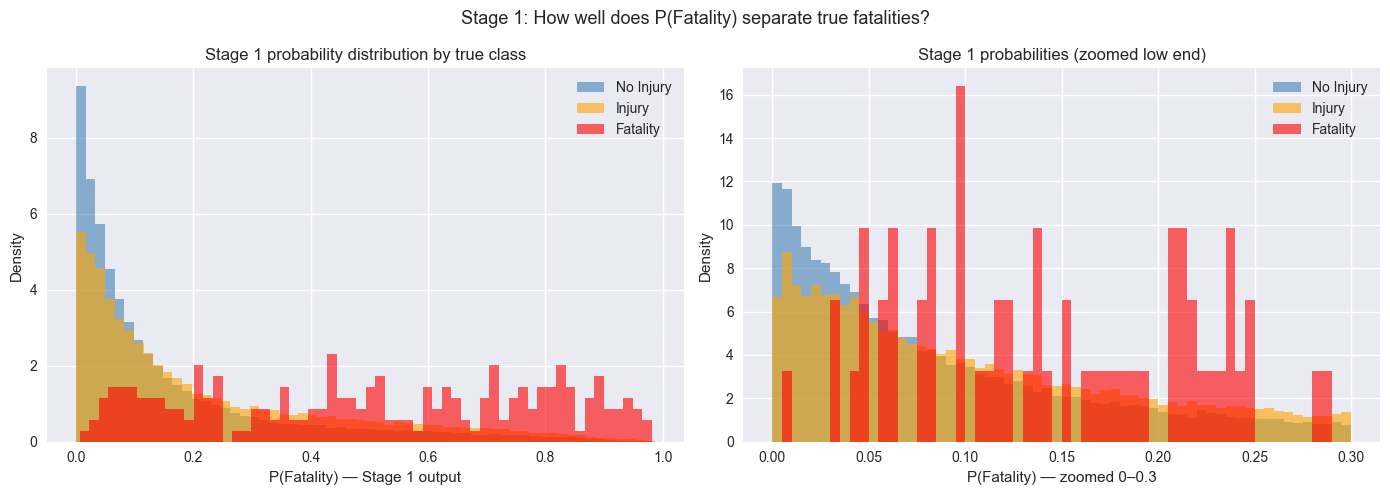

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: full range
ax = axes[0]
for cls, name, color in zip([0, 1, 2], CLASS_NAMES, ['steelblue', 'orange', 'red']):
    ax.hist(s1_proba[y_test == cls], bins=60, alpha=0.6, label=name, color=color, density=True)
ax.set_xlabel('P(Fatality) — Stage 1 output')
ax.set_ylabel('Density')
ax.set_title('Stage 1 probability distribution by true class')
ax.legend(); ax.grid(True)

# right: zoom on 0–0.2 to see where most mass sits
ax = axes[1]
for cls, name, color in zip([0, 1, 2], CLASS_NAMES, ['steelblue', 'orange', 'red']):
    ax.hist(s1_proba[y_test == cls], bins=60, alpha=0.6, label=name, color=color, density=True, range=(0, 0.3))
ax.set_xlabel('P(Fatality) — zoomed 0–0.3')
ax.set_ylabel('Density')
ax.set_title('Stage 1 probabilities (zoomed low end)')
ax.legend(); ax.grid(True)

plt.suptitle('Stage 1: How well does P(Fatality) separate true fatalities?', fontsize=13)
plt.tight_layout(); plt.show()

---
## 4. Stage 2 — No Injury vs. Injury classifier

In [7]:
nonfatal_mask = (y_train != 2).values
X_train_s2    = X_train.iloc[nonfatal_mask]
y_train_s2    = y_train[nonfatal_mask].reset_index(drop=True)

n0, n1 = (y_train_s2 == 0).sum(), (y_train_s2 == 1).sum()
print(f'Stage 2: No Injury={n0:,}  Injury={n1:,}  ratio={n0/n1:.2f}')

S2_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=n0 / n1,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
stage2 = xgb.XGBClassifier(**S2_PARAMS)
stage2.fit(X_train_s2, y_train_s2, verbose=False)
print('Stage 2 training complete.')

Stage 2: No Injury=171,772  Injury=119,235  ratio=1.44


Stage 2 training complete.


---
## 5. Combine stages and full threshold sweep

We sweep the full range 0.01 → 0.99 and evaluate the complete 3-class combined prediction at each point. The goal is to find the operating point that meets a **Fatality recall target**, not to maximize F1.

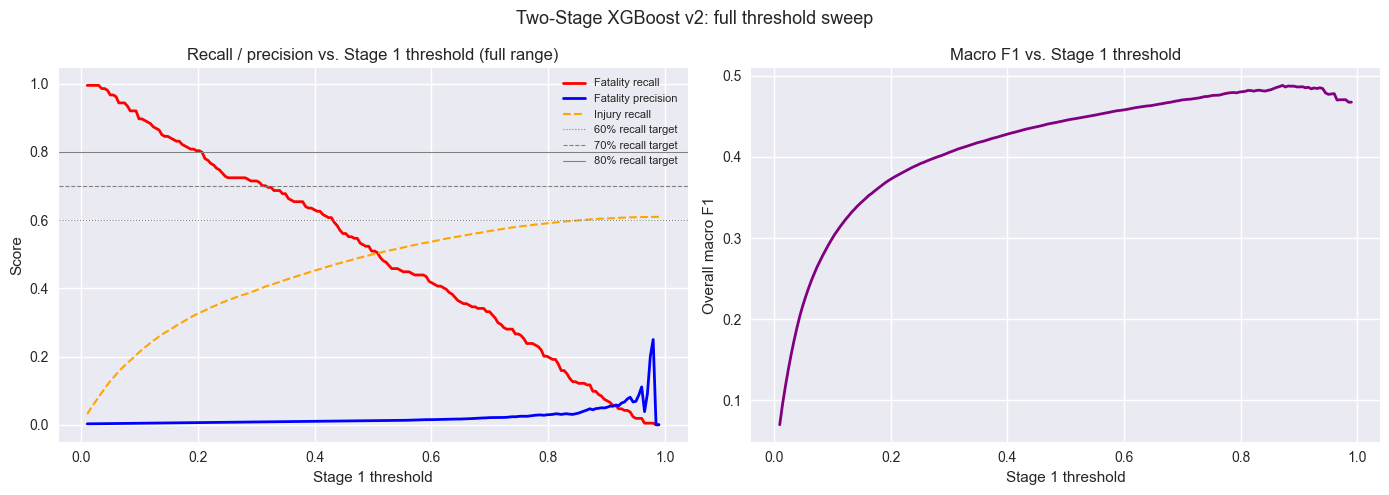

In [8]:
s2_proba   = stage2.predict_proba(X_test)[:, 1]   # P(Injury) — computed once
s2_default = (s2_proba >= 0.5).astype(int)         # Stage 2 default prediction

def predict_combined(s1_thresh):
    s1_pred = (s1_proba >= s1_thresh).astype(int)
    return np.where(s1_pred == 1, 2, s2_default)

thresholds  = np.linspace(0.01, 0.99, 200)
fat_rec, fat_prec, fat_f1 = [], [], []
inj_rec, macro_f1         = [], []

for t in thresholds:
    y_pred = predict_combined(t)
    fat_rec.append(recall_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    fat_prec.append(precision_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    fat_f1.append(f1_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    inj_rec.append(recall_score(y_test, y_pred, labels=[1], average='macro', zero_division=0))
    macro_f1.append(f1_score(y_test, y_pred, average='macro', zero_division=0))

fat_rec   = np.array(fat_rec)
fat_prec  = np.array(fat_prec)
inj_rec   = np.array(inj_rec)
macro_f1  = np.array(macro_f1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, fat_rec,  color='red',    linewidth=2, label='Fatality recall')
ax.plot(thresholds, fat_prec, color='blue',   linewidth=2, label='Fatality precision')
ax.plot(thresholds, inj_rec,  color='orange', linewidth=1.5, linestyle='--', label='Injury recall')
for target, ls in [(0.60, ':'), (0.70, '--'), (0.80, '-')]:
    ax.axhline(target, color='gray', linestyle=ls, linewidth=0.8, label=f'{target:.0%} recall target')
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Score')
ax.set_title('Recall / precision vs. Stage 1 threshold (full range)')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.plot(thresholds, macro_f1, color='purple', linewidth=2)
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Overall macro F1')
ax.set_title('Macro F1 vs. Stage 1 threshold')
ax.grid(True)

plt.suptitle('Two-Stage XGBoost v2: full threshold sweep', fontsize=13)
plt.tight_layout(); plt.show()

---
## 6. Vision Zero operating points

Instead of picking the threshold that maximizes F1 (which is precision-recall balanced and penalizes false positives), we pick thresholds that hit specific **Fatality recall targets**. For Vision Zero — where the mission is eliminating traffic fatalities — the cost of a missed fatality is far higher than the cost of investigating a false alarm.

In [9]:
recall_targets = [0.50, 0.60, 0.70, 0.75, 0.80]
operating_points = []

print(f'{"Target":>8}  {"Threshold":>10}  {"Fat Recall":>11}  {"Fat Prec":>9}  {"Inj Recall":>11}  {"Macro F1":>9}')
print('-' * 70)

for target in recall_targets:
    # find the highest threshold that still achieves >= target recall
    candidates = np.where(fat_rec >= target)[0]
    if len(candidates) == 0:
        print(f'{target:>7.0%}  not achievable')
        continue
    idx = candidates[-1]   # highest threshold still meeting target
    t   = thresholds[idx]
    operating_points.append({
        'target': target, 'threshold': t, 'idx': idx
    })
    print(f'{target:>7.0%}  {t:>10.4f}  '
          f'{fat_rec[idx]:>10.4f}  {fat_prec[idx]:>9.4f}  '
          f'{inj_rec[idx]:>10.4f}  {macro_f1[idx]:>9.4f}')

  Target   Threshold   Fat Recall   Fat Prec   Inj Recall   Macro F1
----------------------------------------------------------------------
    50%      0.5074      0.5047     0.0120      0.5032     0.4461
    60%      0.4286      0.6075     0.0108      0.4669     0.4336
    70%      0.3153      0.7009     0.0084      0.4052     0.4097
    75%      0.2316      0.7523     0.0067      0.3509     0.3849
    80%      0.2021      0.8037     0.0064      0.3275     0.3733


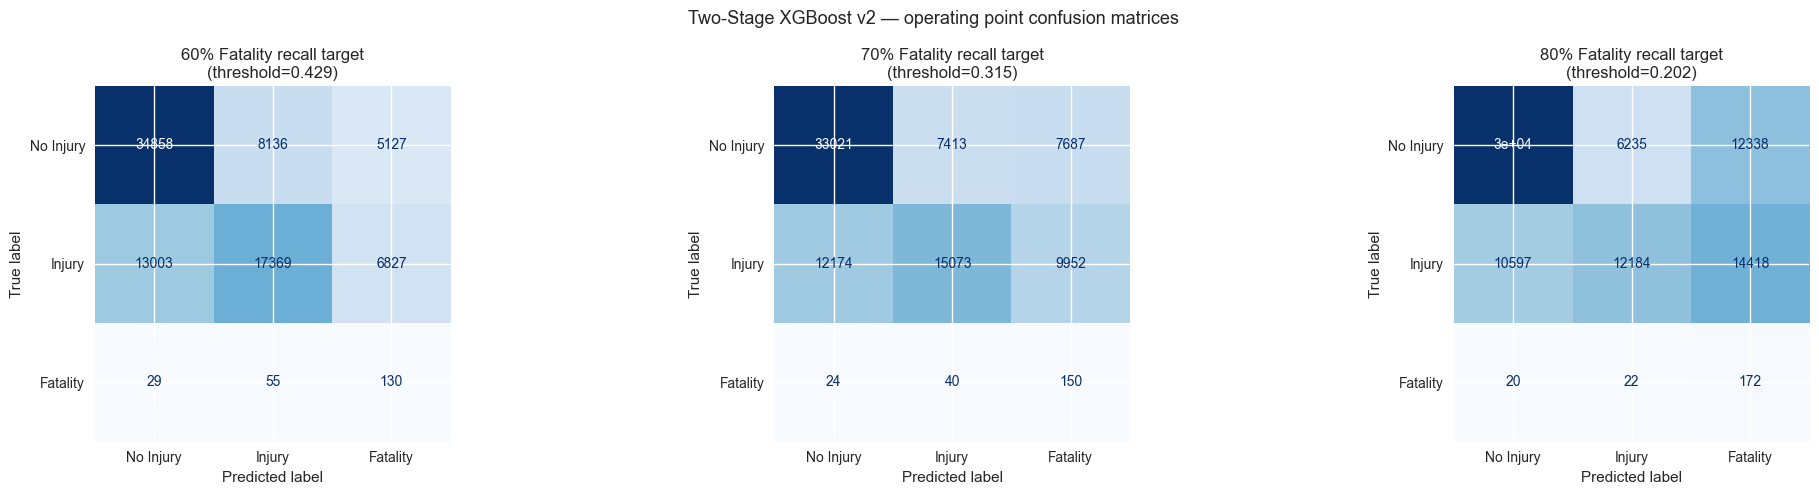

In [10]:
# show confusion matrices for 60%, 70%, 80% recall targets
targets_to_plot = [op for op in operating_points if op['target'] in [0.60, 0.70, 0.80]]
if len(targets_to_plot) > 0:
    fig, axes = plt.subplots(1, len(targets_to_plot), figsize=(7 * len(targets_to_plot), 5))
    if len(targets_to_plot) == 1:
        axes = [axes]
    for ax, op in zip(axes, targets_to_plot):
        y_pred = predict_combined(op['threshold'])
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES
        ).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{op['target']:.0%} Fatality recall target\n(threshold={op['threshold']:.3f})")
    plt.suptitle('Two-Stage XGBoost v2 — operating point confusion matrices', fontsize=13)
    plt.tight_layout(); plt.show()

---
## 7. Full model comparison

We compare all models at their best reported performance AND at a fixed 60% Fatality recall level (the XGBoost multi-class score) for a fair apples-to-apples comparison of macro F1.

In [11]:
# find the 60% recall operating point for this model
op_60 = next((op for op in operating_points if op['target'] == 0.60), None)
op_70 = next((op for op in operating_points if op['target'] == 0.70), None)

rows = [
    {'Model': 'Logistic Regression',           'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'Random Forest v1',              'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'RF cleaner model',              'Macro F1': 0.471, 'Fatality Recall': 0.196, 'Injury Recall': 0.560},
    {'Model': 'RF + SMOTE',                   'Macro F1': 0.497, 'Fatality Recall': 0.112, 'Injury Recall': 0.567},
    {'Model': 'XGBoost multi-class (tuned)',   'Macro F1': 0.434, 'Fatality Recall': 0.603, 'Injury Recall': 0.479},
    {'Model': 'Two-Stage v1 (best F1 t=0.80)','Macro F1': 0.480, 'Fatality Recall': 0.201, 'Injury Recall': 0.591},
    {'Model': 'LinearSVC',                     'Macro F1': 0.459, 'Fatality Recall': 0.089, 'Injury Recall': 0.441},
    {'Model': 'RBF SVC',                       'Macro F1': 0.429, 'Fatality Recall': 0.355, 'Injury Recall': 0.560},
]

if op_60:
    y_pred_60 = predict_combined(op_60['threshold'])
    rows.append({
        'Model': f'Two-Stage v2 (60% recall, t={op_60["threshold"]:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_60, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_60, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_60, labels=[1], average='macro', zero_division=0), 3),
    })

if op_70:
    y_pred_70 = predict_combined(op_70['threshold'])
    rows.append({
        'Model': f'Two-Stage v2 (70% recall, t={op_70["threshold"]:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_70, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_70, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_70, labels=[1], average='macro', zero_division=0), 3),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                             Model  Macro F1  Fatality Recall  Injury Recall
               Logistic Regression     0.430            0.000          0.430
                  Random Forest v1     0.430            0.000          0.430
                  RF cleaner model     0.471            0.196          0.560
                        RF + SMOTE     0.497            0.112          0.567
       XGBoost multi-class (tuned)     0.434            0.603          0.479
     Two-Stage v1 (best F1 t=0.80)     0.480            0.201          0.591
                         LinearSVC     0.459            0.089          0.441
                           RBF SVC     0.429            0.355          0.560
Two-Stage v2 (60% recall, t=0.429)     0.434            0.607          0.467
Two-Stage v2 (70% recall, t=0.315)     0.410            0.701          0.405


---
## 8. Stage 1 feature importance

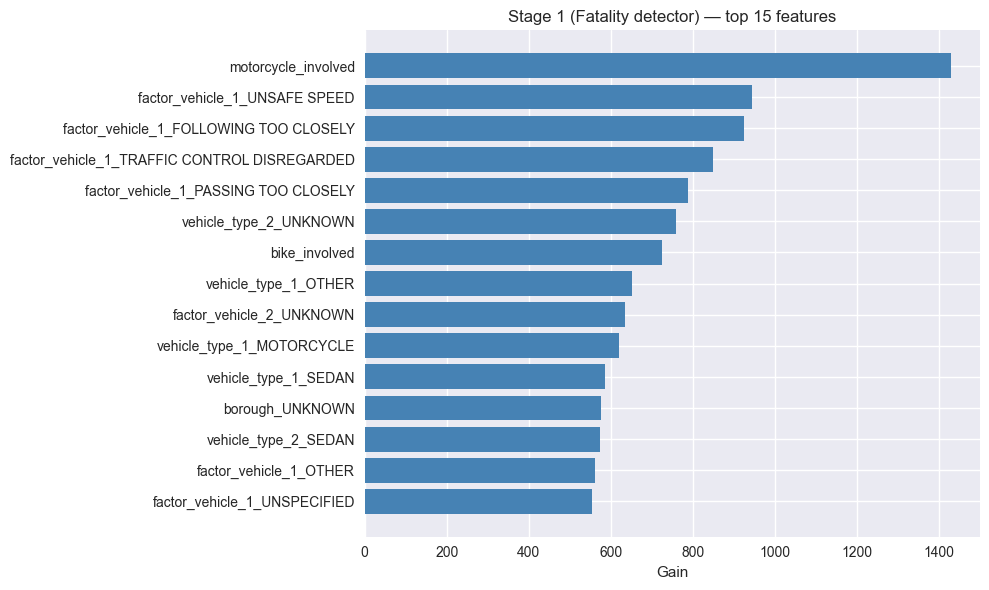

                                                     gain
motorcycle_involved                           1428.897583
factor_vehicle_1_UNSAFE SPEED                  944.514343
factor_vehicle_1_FOLLOWING TOO CLOSELY         926.023254
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED   848.167297
factor_vehicle_1_PASSING TOO CLOSELY           787.525513
vehicle_type_2_UNKNOWN                         759.621216
bike_involved                                  723.971619
vehicle_type_1_OTHER                           652.649658
factor_vehicle_2_UNKNOWN                       635.416077
vehicle_type_1_MOTORCYCLE                      620.181213
vehicle_type_1_SEDAN                           587.000183
borough_UNKNOWN                                577.220398
vehicle_type_2_SEDAN                           573.224304
factor_vehicle_1_OTHER                         561.280579
factor_vehicle_1_UNSPECIFIED                   554.319763


In [12]:
raw = stage1.get_booster().get_score(importance_type='gain')
imp = (pd.DataFrame.from_dict(raw, orient='index', columns=['gain'])
         .sort_values('gain', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp.index[::-1], imp['gain'][::-1], color='steelblue')
ax.set_xlabel('Gain'); ax.set_title('Stage 1 (Fatality detector) — top 15 features')
plt.tight_layout(); plt.show()
print(imp.to_string())